<a href="https://colab.research.google.com/github/NazHub1993/Deep-Learning/blob/main/Handwritten_Digits(Neural_Network).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [16]:
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

In [17]:
len(x_train)

60000

#So there are 6000 images of digits

In [18]:
len(y_train)

60000

In [19]:
x_train[0].shape

(28, 28)

#Each image is a 28x28 grid

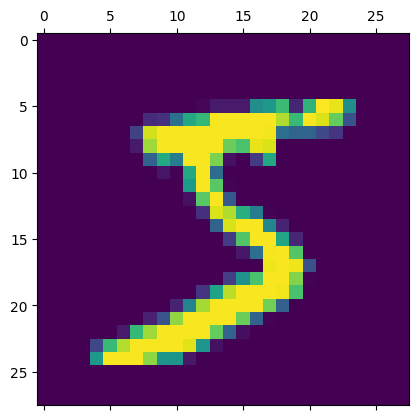

In [20]:
plt.matshow(x_train[0])

In [21]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [22]:
print(f"Number of unique outputs in y_train: {len(np.unique(y_train))}")

Number of unique outputs in y_train: 10


In [23]:
x_train_flattened=x_train.reshape(len(x_train),28*28)
x_test_flattened=x_test.reshape(len(x_test),28*28)
print(f"Shape of flattened x_train: {x_train_flattened.shape}")
print(f"Shape of flattened x_test:{x_test_flattened.shape}")

Shape of flattened x_train: (60000, 784)
Shape of flattened x_test:(10000, 784)


In [24]:
x_train_normalized=x_train_flattened/255
x_test_normalized=x_test_flattened/255
print(f"First 5 normalized values of x_train_normalized[0]: {x_train_normalized[0][:5]}")

First 5 normalized values of x_train_normalized[0]: [0. 0. 0. 0. 0.]


#We want to convert each 28x28 image to a 784 size flattened array!!!.

In [25]:
x_train_flattened[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [26]:
model=keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(x_train_normalized,y_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8778 - loss: 0.4666
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9158 - loss: 0.3038
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9207 - loss: 0.2833
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9238 - loss: 0.2733
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9256 - loss: 0.2668


In [27]:
model.evaluate(x_test_normalized,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9252 - loss: 0.2689


[0.26893162727355957, 0.9251999855041504]

#Accuracy=92%

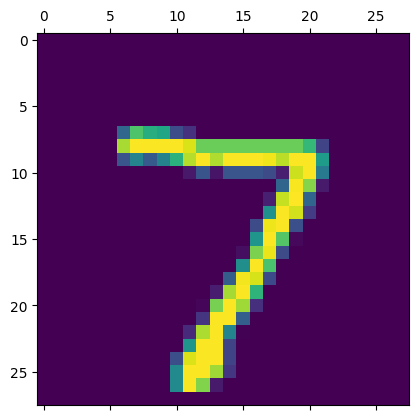

In [28]:
plt.matshow(x_test[0])

In [29]:
y_test[0]

np.uint8(7)

In [33]:
y_test[2]

np.uint8(1)

In [32]:
y_predicted=model.predict(x_test_normalized)
np.argmax(y_predicted[0])


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


np.int64(7)

In [34]:
np.argmax(y_predicted[2])


np.int64(1)

In [35]:
y_predicted_labels=[np.argmax(i) for i in y_predicted]

In [36]:
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [37]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [38]:
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 962,    0,    2,    2,    0,    6,    5,    2,    1,    0],
       [   0, 1110,    3,    2,    0,    1,    4,    2,   13,    0],
       [   6,    9,  925,   13,   10,    5,   12,   10,   39,    3],
       [   4,    0,   21,  905,    1,   38,    2,   10,   20,    9],
       [   1,    1,    3,    1,  936,    0,   10,    3,   10,   17],
       [   9,    3,    4,   18,   12,  797,   12,    3,   29,    5],
       [  12,    3,    6,    1,    8,   16,  907,    2,    3,    0],
       [   1,    5,   21,    5,   11,    1,    0,  947,    5,   32],
       [   6,    7,    7,   16,    9,   34,    9,   10,  870,    6],
       [  11,    7,    1,    9,   49,   10,    0,   22,    7,  893]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Actual')

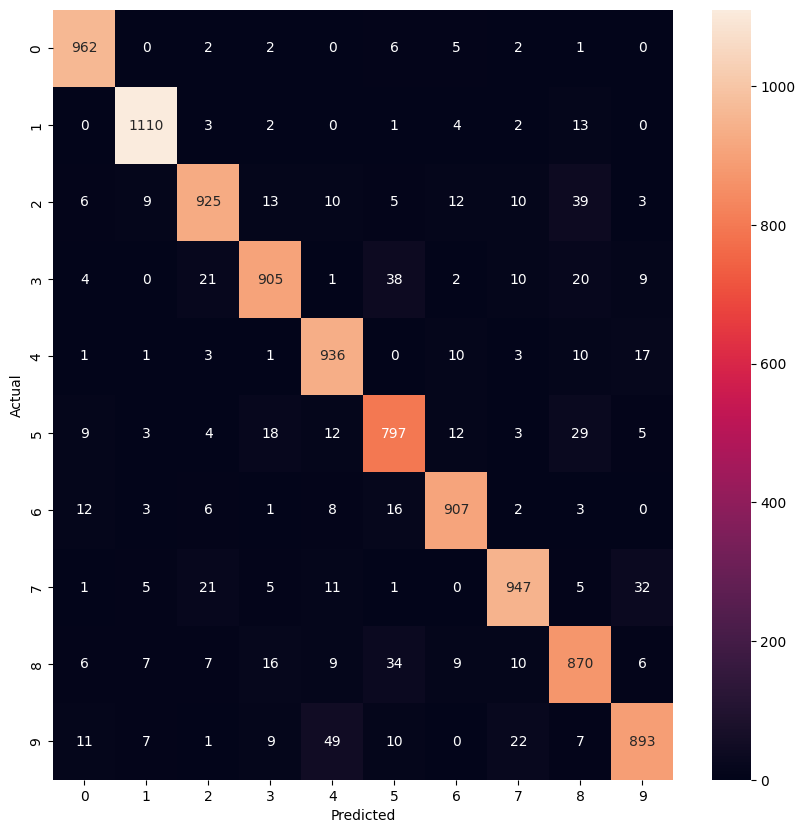

In [40]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

#Now creating hidden layers to improve accuracy

In [44]:
model=keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train_normalized,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9231 - loss: 0.2699
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9643 - loss: 0.1191
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9747 - loss: 0.0856
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9808 - loss: 0.0651
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9843 - loss: 0.0517


In [45]:
model.evaluate(x_test_normalized,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9763 - loss: 0.0769


[0.07689037173986435, 0.9763000011444092]

#After hidden layers accuracy improves to 97%